In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

import gdsfactory as gf
# gf.gpdk.PDK.activate()


%matplotlib widget
# import mplcursors
# from mpl_interactions import zoom_factory
# import addcopyfighandler

total_start = time.time()

# ----------------------------------------------------------------------------------
# Lumerical API path (uncomment for your machine) 
# ----------------------------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  # QP5
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP3
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP2

# ----------------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------------
WORKDIR   = Path().resolve()        # D:\...\scripts\directional_coupler
REPO_ROOT = WORKDIR.parents[1]     # D:\Ligentic_NU_1_TapeOut_April2026
os.chdir(WORKDIR)

data_save_dir = REPO_ROOT / "results_data" / "Data_AQH_4x4_test"
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORKDIR)
print("Data save   :", data_save_dir)

Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingCoupled_fullwave
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_AQH_4x4_test


In [2]:
#------------------------------------------------------------
# LUMERICAL SESSION
#------------------------------------------------------------
import lumapi as lm

f = lm.MODE()

LumFileName = "Test_AQH_4x4_FCGap_600nm.lms"
LumFilePath = str(WORKDIR / LumFileName)
f.save(LumFilePath)

f.switchtolayout()
f.selectall()
f.delete()

C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


Frequency Points: 4000
Min: (0.00, -539.65) µm
Max: (1000.00, 0.60) µm
Center: (500.00, -269.53) µm
Span: 1000.00 x 540.25 µm
Data file: D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_AQH_4x4_test\Test_AQH_4x4_FCGap_600nm_Rings_R25um_W1200nm_Gap300nm_Lc40um_decay1e-05.txt


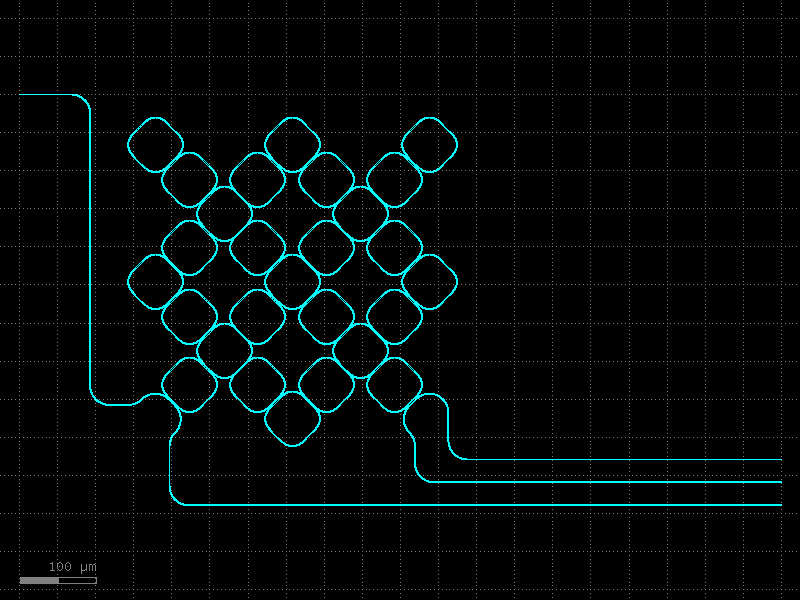

In [3]:
#------------------------------------------------------------
# PARAMETERS 
#------------------------------------------------------------
LambdaStart    = 1545E-9
LambdaStop     = 1553E-9

Height         = 800E-9
XLength        = 100E-6
YLength        = 15E-6

Material           = "Si3N4 (Silicon Nitride) - Luke"
use_index          = True
Index              = 1.97        # optional, used if material = '<Object defined dielectric>'
BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 100E-12
FrequencyPoints    = 4000
decay_rate         = 1E-5

print(f"Frequency Points: {FrequencyPoints}")


#------------------------------------------------------------
# GEOMETRY SETUP (LOAD EXISTING)
#------------------------------------------------------------
gf.clear_cache()

gds_path = str(WORKDIR / "Test_AQH_4x4_FCGap_600nm.gds")
device   = gf.import_gds(gds_path)

# Extract the bounding box
bbox = device.bbox()

xmin, ymin = bbox.left, bbox.bottom
xmax, ymax = bbox.right, bbox.top
center_x   = (xmin + xmax) / 2.0
center_y   = (ymin + ymax) / 2.0
span_x     = xmax - xmin
span_y     = ymax - ymin

# Verification
print(f"Min: ({xmin:.2f}, {ymin:.2f}) µm")
print(f"Max: ({xmax:.2f}, {ymax:.2f}) µm")
print(f"Center: ({center_x:.2f}, {center_y:.2f}) µm")
print(f"Span: {span_x:.2f} x {span_y:.2f} µm")
# Verify geometry
device.plot()

#------------------------------------------------------------
# Parameters (from gds)
#------------------------------------------------------------

InLneghtX    = 100E-6 #from gds
BendRadiusIO = 25E-6
Radius       = 25E-6
FCGap        = 600E-9
Gap          = 300E-9
WgWidth      = 1.2E-6
IO_to_IO_span_x = 457.7E-6
Lc           = 40.0E-6

tag      = f"Test_AQH_4x4_FCGap_{FCGap*1e9:.0f}nm_Rings_R{Radius*1e6:.0f}um_W{WgWidth*1e9:.0f}nm_Gap{Gap*1e9:.0f}nm_Lc{Lc*1e6:.0f}um_decay{decay_rate:.0e}"
fname    = data_save_dir / f"{tag}.txt"
print(f"Data file: {fname}")


In [4]:
f.switchtolayout()
f.selectall()
f.delete()

#------------------------------------------------------------
# GDS load to Lum
#------------------------------------------------------------

device.write_gds(gds_path)
f.gdsimport(gds_path, device.name, "2:0", Material, 0, Height)

if use_index:
    f.set("material", "<Object defined dielectric>")
    f.set("index", Index)

#------------------------------------------------------------
# BOUNDING BOX & PORTS
#------------------------------------------------------------

margin = 10E-6

offsetX = 6e-6 +(LambdaStart+LambdaStop)/2
offsetY = 2e-6

x_sim = IO_to_IO_span_x/2 +InLneghtX +1*BendRadiusIO
y_sim = -2.75*(2*Radius+Lc+Gap+WgWidth)

x0 = InLneghtX/2
y0 = - 1*(2*Radius+Lc+Gap+WgWidth) -offsetY

Sim_span_x = IO_to_IO_span_x  + 1*BendRadiusIO
Sim_span_y = span_y*1E-6 - 7.0*margin 

SourcePosX =  x_sim-(Sim_span_x/2) +offsetX
SourcePosY =  -357.35E-6 -2*BendRadiusIO
TH_PosX    =  196.90E-6
TH_PosY    =  -BendRadiusIO - 5*(2*Radius+Lc+Gap+WgWidth) + offsetY

# DR_PosX    =  TH_PosX + 365.8E-6 + FCGap
DR_PosX    =  562.7E-6
DR_PosY    =  - 5*(2*Radius+Lc+Gap+WgWidth) + 2*offsetY

Field_PosX = Sim_span_x- 3*margin 
Filed_PosY = Sim_span_y- 3*margin 

#------------------------------------------------------------
# varFDTD
#------------------------------------------------------------
f.addvarfdtd()
f.set("simulation time", SimulationTime)
f.set("x0", x0)
f.set("y0", y0)
f.set("x", x_sim)
f.set("x span", Sim_span_x)
f.set("y", y_sim)
f.set("y span", Sim_span_y)
f.set("z", Height / 2)
f.set("z span", 8 * Height)
f.set("background material", BackgroundMaterial)
f.set("set simulation bandwidth", 1)
f.set("bandwidth", "broadband")
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min", decay_rate)

f.set("x min bc", "PML")
f.set("x max bc", "PML")
f.set("y min bc", "PML")
f.set("y max bc", "PML")
f.set("z min bc", "PML")
f.set("z max bc", "PML")


In [5]:
#------------------------------------------------------------
# SOURCE — at o3 (input), inject +x
#------------------------------------------------------------
f.addmodesource()
f.set("name", "ModeSource")
f.set("x", SourcePosX)
f.set("y", SourcePosY)
f.set("y span", 3 * WgWidth)
f.set("injection axis", "x-axis")
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("mode selection", "fundamental mode")
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)

#------------------------------------------------------------
# MONITOR: Through
#------------------------------------------------------------
f.adddftmonitor()
f.set("name", "TH")
f.set("monitor type", "Linear X")
f.set("x", TH_PosX)
f.set("y", TH_PosY)
f.set("x span", 3 * WgWidth)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)

#------------------------------------------------------------
# MONITOR: Through (at o4)
#------------------------------------------------------------
f.adddftmonitor()
f.set("name", "DR")
f.set("monitor type", "Linear X")
f.set("x", DR_PosX)
f.set("y", DR_PosY)
f.set("x span", 3 * WgWidth)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)

#------------------------------------------------------------
# MONITOR: Field
#------------------------------------------------------------
f.adddftmonitor()
f.set("name", "Field Monitor")
f.set("monitor type", "2D Z-normal")
f.set("x", x_sim)
f.set("x span",Field_PosX)
f.set("y", y_sim+2*offsetY)
f.set("y span", Filed_PosY)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use wavelength spacing", 1)
f.set("wavelength center", 1548.5E-9)
f.set("wavelength span", 1E-9)
f.set("frequency points", 1)

f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)


In [ ]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------

f.run()


In [ ]:

#------------------------------------------------------------
# Extract Results
#------------------------------------------------------------
try:
    T_TH = f.getresult("TH", "T")
    T_DR = f.getresult("DR", "T")

    Tx_Through = np.abs(T_TH["T"].flatten())
    Tx_Drop    = np.abs(T_DR["T"].flatten())
    Wavelength = T_TH["lambda"].flatten()
except Exception as e:
    print(f"  ⚠ SKIPPED | {e}")

Tx_total_out = Tx_Through + Tx_Drop

idx_1550        = np.argmin(np.abs(Wavelength - 1550e-9))
loss_dB_1550    = -10 * np.log10(Tx_total_out[idx_1550])

print(f"Loss={loss_dB_1550:.2f} dB")


#------------------------------------------------------------
# E-field plot (save only, no show)
#------------------------------------------------------------
E_field    = f.getresult("Field Monitor", "E")
idx_1550_E = np.argmin(np.abs(E_field['lambda'].flatten() - 1550e-9))


fig_path = data_save_dir / f"Efield_{tag}.png"

try:
    x = E_field['x'].flatten() * 1e6
    y = E_field['y'].flatten() * 1e6
    E_int = np.abs(E_field['E'][:, :, 0, idx_1550_E, 1]).T**2
    E_dB  = 10 * np.log10(E_int / E_int.max() + 1e-20)
    
    # --- Save Data ---
    X, Y = np.meshgrid(x, y)
    np.savetxt(data_save_dir / f"Efield_Data_{tag}.txt", 
            np.column_stack((X.flatten(), Y.flatten(), E_int.flatten())), 
            delimiter=",", header="x_um,y_um,Ey_intensity", comments="")
    # -------------------------

    plt.figure(figsize=(20, 20))
    plt.imshow(E_dB,
            aspect='auto', cmap='hot', origin='lower',
            extent=[x.min(), x.max(), y.min(), y.max()],
            vmin=-40, vmax=0)
    plt.xlabel('x (µm)')
    plt.ylabel('y (µm)')
    plt.colorbar(label='|Ey|² (dB)')
    plt.title(f'Field Profile at 1548.5nm | {tag}')
    plt.savefig(fig_path, dpi=600, bbox_inches='tight')
    plt.close('all')
except Exception as e:
    print(f"  E-field save failed: {e}")
    plt.close('all')



In [ ]:

#------------------------------------------------------------
# Plot
#------------------------------------------------------------
fig1 = plt.figure()
plt.plot(Wavelength*1e9, Tx_Through, label="Through")
plt.plot(Wavelength*1e9, Tx_Drop,    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission")
plt.title(f"{tag}", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(data_save_dir / f"{fname}_lin.png", dpi=300, bbox_inches='tight')
# mplcursors.cursor(hover=True)
# disconnect_zoom = zoom_factory(plt.gca())
plt.show()

fig2 = plt.figure()
plt.plot(Wavelength*1e9, 10*np.log10(Tx_Through), label="Through")
plt.plot(Wavelength*1e9, 10*np.log10(Tx_Drop),    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (dB)")
plt.title(f" {tag}",fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(data_save_dir / f"{fname}.png", dpi=300, bbox_inches='tight')
# mplcursors.cursor(hover=True)
# disconnect_zoom = zoom_factory(plt.gca())
plt.show()

#------------------------------------------------------------
# Save Data
#------------------------------------------------------------

meta = {
    "Width_nm"          : WgWidth  * 1e9,
    "Height_nm"         : Height * 1e9,
    "Radius_um"         : Radius * 1e6,
    "Gap_nm"            : Gap    * 1e9,
    "FCGap_nm"          : FCGap * 1e9, 
    "Lc_um"             : Lc * 1e6,
    "Material"          : Material,
    "Index"             : Index,
    "use_index"         : use_index,
    "Timestamp"         : time.strftime("%Y%m%d_%H%M%S"),
}

with open(fname, "w") as file:
    for k, v in meta.items():
        file.write(f"# {k}: {v}\n")
    file.write("# Wavelength_nm\tTx_Through\tTx_Drop\n")

data = np.column_stack([Wavelength*1e9, Tx_Through, Tx_Drop])
with open(fname, "ab") as file:
    np.savetxt(file, data, delimiter="\t")

print(f"Saved: {fname}")